Model                |       R² |     RMSE |      MAE
-------------------------------------------------------
Ridge                |    0.697 |    1.552 |    1.215
Lasso                |    0.672 |    1.614 |    1.269
SVR                  |    0.785 |    1.307 |    1.031
RandomForest         |    0.843 |    1.116 |    0.831
GradientBoosting     |    0.875 |    0.996 |    0.766
XGBoost              |    0.850 |    1.091 |    0.807


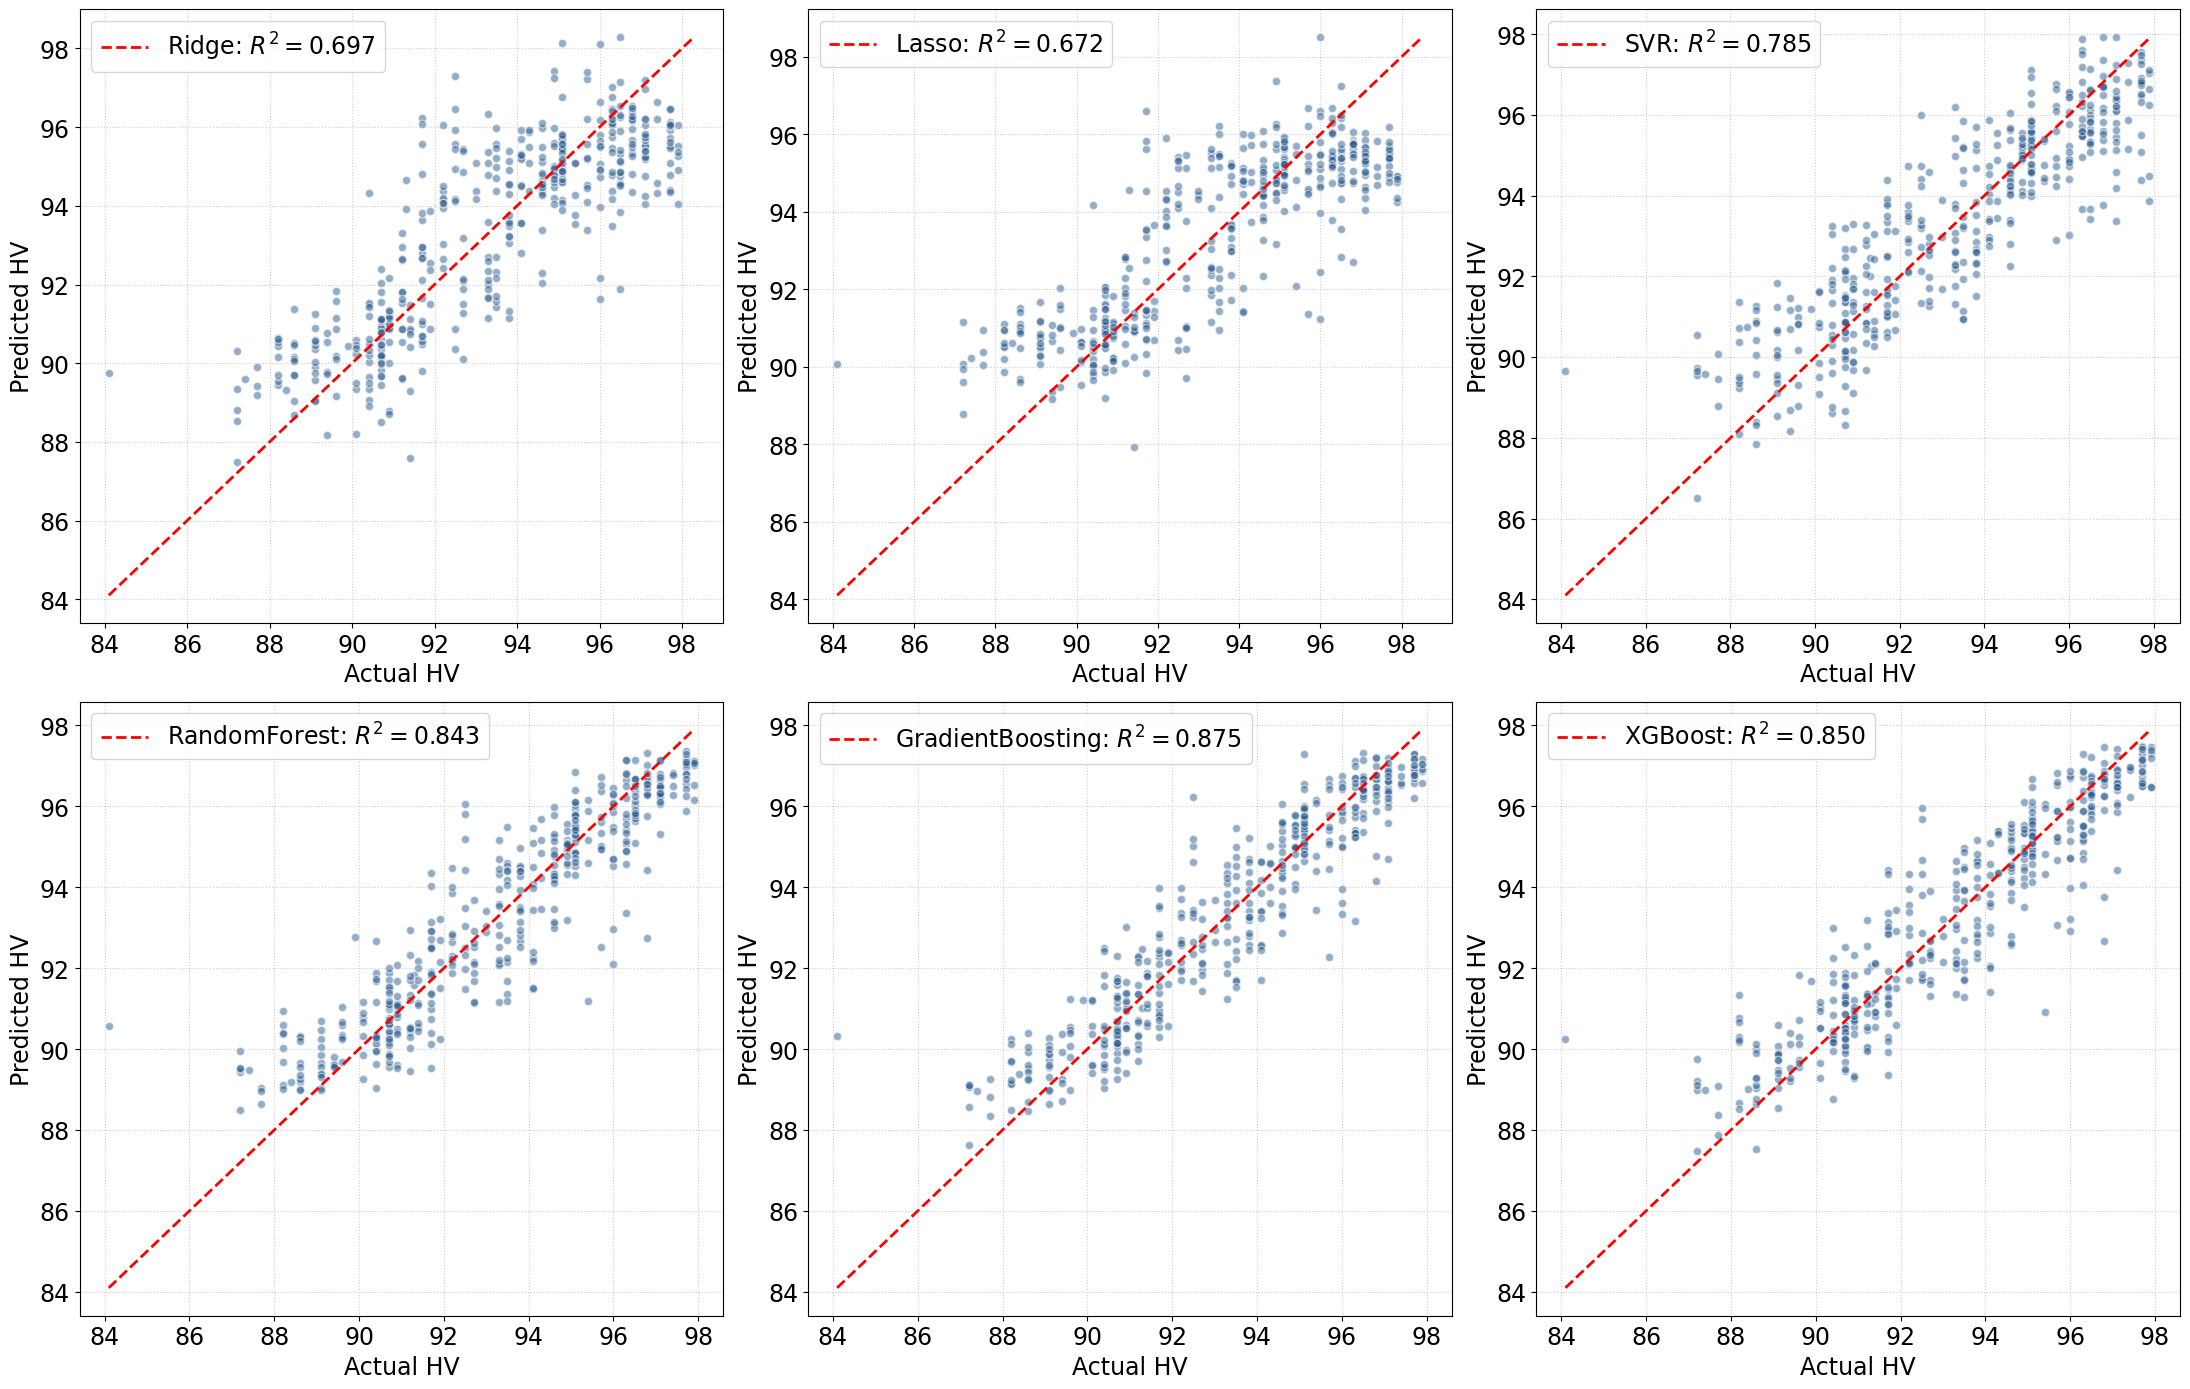


=== Model Comparison (sorted by R²) ===
           Model    R2  RMSE   MAE
GradientBoosting 0.875 0.996 0.766
         XGBoost 0.850 1.091 0.807
    RandomForest 0.843 1.116 0.831
             SVR 0.785 1.307 1.031
           Ridge 0.697 1.552 1.215
           Lasso 0.672 1.614 1.269

✅ 완료: 지정하신 6개 모델을 기반으로 고해상도 그래프 플로팅 및 결과 저장이 완료되었습니다.


In [2]:
import json
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# 저장 디렉토리 안전하게 확인 및 생성
output_dir = r".\data\figure"
os.makedirs(output_dir, exist_ok=True)

# 1. 데이터 로드 및 전처리
df_filtered = pd.read_csv(r".\data\c_cleaned_hv_with_features.csv")

hv_cols = ["HV"]
drop_cols = ["FILE_NAME"] + hv_cols
feat_cols = [c for c in df_filtered.columns if c not in drop_cols and c in df_filtered.columns]

df_filtered[feat_cols] = df_filtered[feat_cols].fillna(0)
X = df_filtered[feat_cols].values
y = df_filtered["HV"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 모델 설정 (6개 모델 지정)
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "SVR": SVR(kernel="rbf", C=10),
    "RandomForest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200, learning_rate=0.05, random_state=42
    ),
}

# 3. KFold 설정 (일반 교차 검증)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. 모델 교차 검증 및 그래프 생성
results = []

# 6개 모델에 맞게 2행 3열 구조로 변경
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(22, 14))
axes = axes.flatten()

print(f"{'Model':<20} | {'R²':>8} | {'RMSE':>8} | {'MAE':>8}")
print("-" * 55)

for i, (name, model) in enumerate(models.items()):
    # Cross Validation 예측
    y_pred = cross_val_predict(model, X_scaled, y, cv=kf)

    # 평가지표 계산
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    results.append(
        {"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae}
    )
    print(
        f"{name:<20} | {r2:>8.3f} | {rmse:>8.3f} | {mae:>8.3f}"
    )

    # 범위 기준값 계산
    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())

    # -------------------------------------------------------------------------
    # 개별 모델 독립 그래프 저장 (300 DPI, 제목 없음, 폰트 17)
    # -------------------------------------------------------------------------
    fig_single, ax_single = plt.subplots(figsize=(7, 7))

    ax_single.scatter(
        y, y_pred, alpha=0.6, edgecolors="w", color="#2b5c8f", s=50
    )
    ax_single.plot(
        [min_val, max_val],
        [min_val, max_val],
        "r--",
        lw=2,
        label=f"$R^2 = {r2:.3f}$",
    )

    ax_single.set_xlabel("Actual HV", fontsize=17)
    ax_single.set_ylabel("Predicted HV", fontsize=17)
    ax_single.tick_params(axis="both", labelsize=17)

    ax_single.legend(loc="upper left", fontsize=17, frameon=True)
    ax_single.grid(True, linestyle=":", alpha=0.6)

    fig_single.tight_layout()
    single_save_path = os.path.join(
        output_dir, f"{name.lower()}_actual_vs_predicted_.png"
    )
    fig_single.savefig(single_save_path, dpi=300, bbox_inches="tight")
    plt.close(fig_single)

    # -------------------------------------------------------------------------
    # 통합 그리드 플롯 구성 (제목 없음, 폰트 17)
    # -------------------------------------------------------------------------
    ax = axes[i]
    ax.scatter(y, y_pred, alpha=0.5, edgecolors="w", color="#2b5c8f")
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "r--",
        lw=2,
        label=f"{name}: $R^2 = {r2:.3f}$",
    )

    ax.set_xlabel("Actual HV", fontsize=17)
    ax.set_ylabel("Predicted HV", fontsize=17)
    ax.tick_params(axis="both", labelsize=17)

    ax.legend(loc="upper left", fontsize=17, frameon=True)
    ax.grid(True, linestyle=":", alpha=0.6)

# 사용하지 않는 빈 서브플롯 축 삭제 (6개 모델이 축 6개를 채우므로 여기서는 수행되지 않음)
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

# 통합 이미지 고해상도 저장
fig.tight_layout()
grid_save_path = os.path.join(output_dir, "cv_actual_vs_predicted_all_.png")
fig.savefig(grid_save_path, dpi=300, bbox_inches="tight")
plt.show()

# 5. 결과 테이블 출력 및 저장
df_results = (
    pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
)
print("\n=== Model Comparison (sorted by R²) ===")
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
df_results.to_csv(r".\data\model_comparison_results.csv", index=False)

print(
    "\n✅ 완료: 지정하신 6개 모델을 기반으로 고해상도 그래프 플로팅 및 결과 저장이 완료되었습니다."
)